In [87]:
from importlib import reload
import os
import sys
# Set up paths for utility imports
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utils')

os.chdir(current_dir)
# Ensure the utilities directory is in the import path
if utilities_dir not in sys.path:
    sys.path.insert(0, utilities_dir)
    
import plotting
import pinns
import numpy as np
import matplotlib.pyplot as plt 
import torch
import torch.nn as nn
import torch.optim as optim
 
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from pinns import  MLP, init_weights 

In [101]:
# --------------------------------------------------
# Parameters
# --------------------------------------------------

alpha = 0.5
beta = 5
epsilon = 1.0

# --------------------------------------------------
# Analytical solution
# --------------------------------------------------

def analytical_solution(x, y, alpha=alpha, beta=beta):
    """
    Analytical solution u(x,y).
    """
    return np.exp(-alpha * (x**2 + y**2)) * np.cos(beta * y)


def coefficient(x, y, epsilon=epsilon):
    """
    Variable coefficient k(y).
    """
    return 1 + 2 / (1 + np.exp(-y / epsilon))

In [102]:
results = []
iter_train = 0

adam_lr        = 1e-3
hidden_layers_ = 3
hidden_units_  = 25
 
adam_iters     = 1_000
lbfgs_iters    = 5_000
activation_function_ = nn.Tanh()


device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

model = MLP(
    input_size=2,
    output_size=1,
    hidden_layers=hidden_layers_,
    hidden_units=hidden_units_,
    activation_function=activation_function_,
).to(device)

model.apply(init_weights)

MLP(
  (linear_in): Linear(in_features=2, out_features=25, bias=True)
  (linear_out): Linear(in_features=25, out_features=1, bias=True)
  (layers): ModuleList(
    (0-2): 3 x Linear(in_features=25, out_features=25, bias=True)
  )
  (act): Tanh()
)

In [ ]:
np.random.seed(42)

N_obs = 1000

x_obs = np.random.uniform(-5, 5, N_obs)
y_obs = np.random.uniform(-5, 5, N_obs)

u_obs = analytical_solution(x_obs, y_obs)
k_obs = coefficient(x_obs, y_obs)

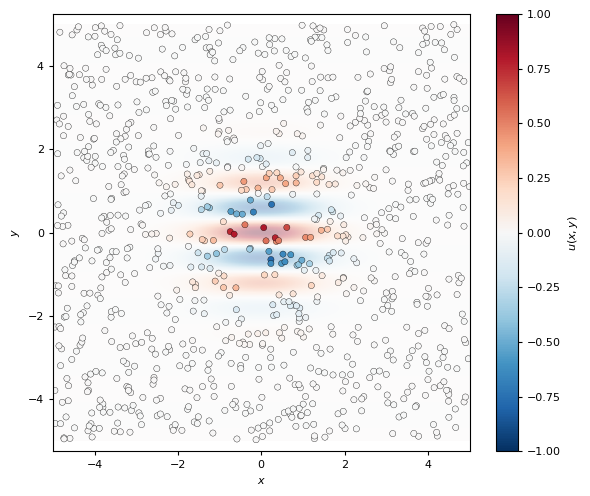

In [ ]:

# Dense field for visualization
x = np.linspace(-5, 5, 300)
y = np.linspace(-5, 5, 300)

X, Y = np.meshgrid(x, y)
U = analytical_solution(X, Y)

plt.figure(figsize=(6, 5))

# Background analytical solution
plt.imshow(
    U,
    extent=[-5, 5, -5, 5],
    origin="lower",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    alpha=0.35,
)

# Observation points colored by the analytical solution
sc = plt.scatter(
    x_obs,
    y_obs,
    c=u_obs,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    s=20,
    edgecolors="k",
    linewidths=0.25,
)

plt.colorbar(sc, label=r"$u(x,y)$")

plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.axis("equal")

plt.tight_layout()
plt.show()

In [105]:
# ============================================================
# Training data
# ============================================================

X_train = torch.tensor(
    np.column_stack((x_obs, y_obs)),
    dtype=torch.float32,
    device=device,
)

U_train = torch.tensor(
    u_obs.reshape(-1,1),
    dtype=torch.float32,
    device=device,
)

In [106]:

# ============================================================
# Optimizers
# ============================================================

criterion = nn.MSELoss()

optimizer_adam = optim.Adam(
    model.parameters(),
    lr=adam_lr,
)

optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    lr=1,
    max_iter=lbfgs_iters,
    max_eval=lbfgs_iters,
    tolerance_grad=1e-7,
    history_size=100,
    tolerance_change=1.0 * np.finfo(float).eps,
    line_search_fn="strong_wolfe"
)


loss_history = []

# ==========================================================
# Adam
# ==========================================================

model.train()

for epoch in range(adam_iters):

    optimizer_adam.zero_grad()

    prediction = model(X_train)

    loss = criterion(prediction, U_train)

    loss.backward()

    optimizer_adam.step()

    loss_history.append(loss.item())

    if epoch % 100 == 0:
        print(f"Adam {epoch:5d} | Loss = {loss.item():.3e}")

state = {"iter": 0}

def closure():

    optimizer_lbfgs.zero_grad()

    prediction = model(X_train)

    loss = criterion(prediction, U_train)

    loss.backward()

    state["iter"] += 1

    if state["iter"] % 10 == 0:
        print(
            f"L-BFGS Iteration {state['iter']:5d} | "
            f"Loss = {loss.item():.6e}"
        )

    return loss

optimizer_lbfgs.step(closure)

Adam     0 | Loss = 7.840e-02
Adam   100 | Loss = 1.379e-02
Adam   200 | Loss = 1.365e-02
Adam   300 | Loss = 1.350e-02
Adam   400 | Loss = 1.329e-02
Adam   500 | Loss = 1.298e-02
Adam   600 | Loss = 1.254e-02
Adam   700 | Loss = 1.192e-02
Adam   800 | Loss = 1.109e-02
Adam   900 | Loss = 9.575e-03
L-BFGS Iteration    10 | Loss = 6.488230e-03
L-BFGS Iteration    20 | Loss = 5.855582e-03
L-BFGS Iteration    30 | Loss = 5.403659e-03
L-BFGS Iteration    40 | Loss = 5.085479e-03
L-BFGS Iteration    50 | Loss = 4.555059e-03
L-BFGS Iteration    60 | Loss = 4.193571e-03
L-BFGS Iteration    70 | Loss = 3.592752e-03
L-BFGS Iteration    80 | Loss = 3.028268e-03
L-BFGS Iteration    90 | Loss = 2.689920e-03
L-BFGS Iteration   100 | Loss = 2.339028e-03
L-BFGS Iteration   110 | Loss = 2.077081e-03
L-BFGS Iteration   120 | Loss = 1.930133e-03
L-BFGS Iteration   130 | Loss = 1.686274e-03
L-BFGS Iteration   140 | Loss = 1.493421e-03
L-BFGS Iteration   150 | Loss = 1.376704e-03
L-BFGS Iteration   160 | 

tensor(0.0070, device='cuda:0', grad_fn=<MseLossBackward0>)

In [107]:
# --------------------------------------------------
# Evaluation grid
# --------------------------------------------------

X_test = torch.tensor(
    np.column_stack((X.ravel(), Y.ravel())),
    dtype=torch.float32,
    device=device,
)

model.eval()

with torch.no_grad():

    prediction = model(X_test)

    # First output corresponds to u
    U_pred = prediction[:, 0]

U_pred = U_pred.cpu().numpy().reshape(U.shape)

In [108]:
relative_l2 = np.linalg.norm(U_pred - U) / np.linalg.norm(U)

print(f"Relative L2 error: {relative_l2:.3e}")

Relative L2 error: 4.949e-02


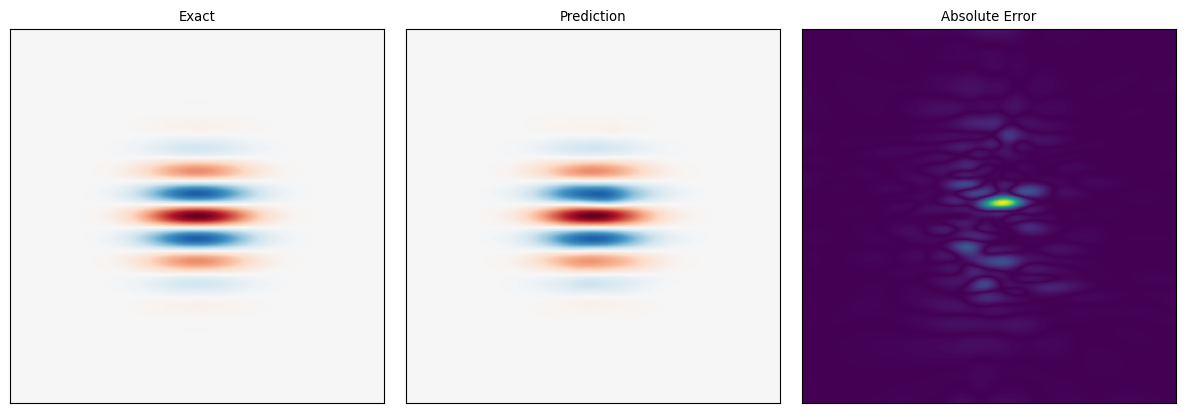

In [109]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

im0 = ax[0].imshow(
    U,
    extent=[-5, 5, -5, 5],
    origin="lower",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
)
ax[0].set_title("Exact")

im1 = ax[1].imshow(
    U_pred,
    extent=[-5, 5, -5, 5],
    origin="lower",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
)
ax[1].set_title("Prediction")

im2 = ax[2].imshow(
    np.abs(U_pred - U),
    extent=[-5, 5, -5, 5],
    origin="lower",
    cmap="viridis",
)
ax[2].set_title("Absolute Error")

for a in ax:
    a.set_xticks([])
    a.set_yticks([])

plt.tight_layout()
plt.show()